# Are crypto "fundamentals" a viable basis for systematic strategies?

**A go / no-go decision notebook.**

The thesis under test: tokens of fee-generating protocols can be ranked on
fundamental valuation metrics (price-to-fees, dilution) and that ranking
predicts forward returns in the cross-section — i.e. there is a value factor
in crypto that is not simply repackaged market direction.

## Decision criteria (fixed before running anything)

The thesis is worth pursuing **only if ALL five hold**:

| # | Criterion | Threshold |
|---|-----------|-----------|
| C1 | Fee data reconciles against protocol sources | within ~10% on spot checks |
| C2 | Usable history | >= 18 months across >= 12 tokens |
| C3 | P/F long-short spread is monotonic-ish across quintiles | not just a lucky extreme bucket |
| C4 | Spread survives regressing out BTC beta | residual signal, not market direction |
| C5 | Spread magnitude clears round-trip costs | ~50-100bp on mid-cap tokens |

Criterion 1 is a **gate**: if fee data does not reconcile, the notebook stops
and says so, because every downstream number would be built on it.

The verdict cell at the bottom evaluates these programmatically, criterion by
criterion. A negative result is reported as a negative result.

**Data:** DefiLlama (protocol fees, free, no key) + CoinGecko free tier
(price, market cap). Every raw JSON response is cached to
`data/crypto_fundamentals_cache/` on first fetch and committed alongside this
notebook, so a re-run is offline, deterministic, and reproduces the numbers
below exactly. The cache is a **snapshot taken 2026-09-07** — delete the
directory to re-fetch live data, which will shift the window forward and
change the numbers.

In [1]:
from __future__ import annotations

import json
import os
import time
import urllib.error
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Repo-relative cache for raw JSON. Everything the notebook uses is fetched
# once and re-read from here, so a re-run is offline and reproducible.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE = REPO / "data" / "crypto_fundamentals_cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("cache:", CACHE)
print(f"cached files present: {len(list(CACHE.glob('*.json')))} "
      f"(delete the directory to re-fetch everything live)")
print(f"run date: {pd.Timestamp.now(tz='UTC').date()}")

# ---------------------------------------------------------------- parameters
COST_BPS_ROUND_TRIP = 75.0   # midpoint of the 50-100bp band in the criteria
FEE_LOOKBACK_D = 30          # trailing window used to annualise fees
DILUTION_LOOKBACK_D = 90     # trailing window for supply-growth rate
N_QUINTILES = 5
HORIZONS = (30, 90)          # forward-return horizons, calendar days
MIN_TOKENS_REQUIRED = 12     # criterion C2
MIN_MONTHS_REQUIRED = 18     # criterion C2
RECON_TOL = 0.10             # criterion C1

cache: /home/user/Bayes-ically-Rich/data/crypto_fundamentals_cache
cached files present: 63 (delete the directory to re-fetch everything live)
run date: 2026-09-07


## 1. Data layer

A single cached fetcher. `get_json` writes every response to
`data/crypto_fundamentals_cache/` keyed by a slug, and thereafter reads from
disk — so the analysis below is deterministic and re-runnable without network.
CoinGecko's free tier is rate-limited, so requests are spaced and 429s are
retried with backoff.

In [2]:
UA = {"User-Agent": "crypto-fundamentals-research/1.0"}
_last_call: dict[str, float] = {}


def _throttle(host: str, min_gap: float) -> None:
    gap = time.time() - _last_call.get(host, 0.0)
    if gap < min_gap:
        time.sleep(min_gap - gap)
    _last_call[host] = time.time()


def get_json(url: str, key: str, min_gap: float = 0.3, max_retries: int = 5,
             refresh: bool = False):
    """Fetch `url`, caching the parsed JSON at CACHE/<key>.json.

    Returns (payload, from_cache). Errors are cached too, as {"__error__": ...},
    so a dead endpoint does not get retried on every re-run — delete the file to
    force a refetch.
    """
    path = CACHE / f"{key}.json"
    if path.exists() and not refresh:
        return json.loads(path.read_text()), True

    host = url.split("/")[2]
    delay = 5.0
    for attempt in range(max_retries):
        _throttle(host, min_gap)
        try:
            req = urllib.request.Request(url, headers=UA)
            with urllib.request.urlopen(req, timeout=90) as resp:
                payload = json.loads(resp.read())
            break
        except urllib.error.HTTPError as exc:
            body = exc.read()[:300].decode("utf-8", "replace")
            if exc.code in (429, 503, 504) and attempt < max_retries - 1:
                time.sleep(delay)
                delay *= 2
                continue
            payload = {"__error__": f"HTTP {exc.code}", "body": body}
            break
        except Exception as exc:  # network / timeout
            if attempt < max_retries - 1:
                time.sleep(delay)
                delay *= 2
                continue
            payload = {"__error__": repr(exc)}
            break

    path.write_text(json.dumps(payload))
    return payload, False


def cache_stats() -> str:
    files = list(CACHE.glob("*.json"))
    mb = sum(f.stat().st_size for f in files) / 1e6
    return f"{len(files)} cached JSON files, {mb:.1f} MB"

### 1.1 Universe

Protocols are picked by rule, not by eye: a DefiLlama fee adapter, a liquid
listed token, and non-trivial current fees. Chains (Solana, Tron, BNB) are
included — their gas fees are as real a revenue line as a DEX's swap fee.

Ethereum-the-chain is deliberately **excluded from the cross-section** even
though it has a fee adapter, because ETH is used as a benchmark; keeping it in
both places would contaminate the benchmark regressions.

In [3]:
# (defillama fee slug, coingecko id, ticker). CoinGecko ids come from
# DefiLlama's own `gecko_id` field where it publishes one; the rest are mapped
# by hand and verified against /coins/list below.
UNIVERSE = [
    ("uniswap",         "uniswap",                     "UNI"),
    ("aave",            "aave",                        "AAVE"),
    ("lido",            "lido-dao",                    "LDO"),
    ("hyperliquid",     "hyperliquid",                 "HYPE"),
    ("jupiter",         "jupiter-exchange-solana",     "JUP"),
    ("raydium",         "raydium",                     "RAY"),
    ("pancakeswap",     "pancakeswap-token",           "CAKE"),
    ("aerodrome",       "aerodrome-finance",           "AERO"),
    ("morpho",          "morpho",                      "MORPHO"),
    ("ethena",          "ethena",                      "ENA"),
    ("jito",            "jito-governance-token",       "JTO"),
    ("ether.fi",        "ether-fi",                    "ETHFI"),
    ("gmx",             "gmx",                         "GMX"),
    ("pendle",          "pendle",                      "PENDLE"),
    ("kamino",          "kamino",                      "KMNO"),
    ("chainlink",       "chainlink",                   "LINK"),
    ("solana",          "solana",                      "SOL"),
    ("tron",            "tron",                        "TRX"),
    ("bsc",             "binancecoin",                 "BNB"),
    ("curve-dex",       "curve-dao-token",             "CRV"),
    ("sky-lending",     "sky",                         "SKY"),
    ("pump.fun",        "pump-fun",                    "PUMP"),
    ("meteora",         "meteora",                     "MET"),
    ("orca",            "orca",                        "ORCA"),
    ("aster",           "aster-2",                     "ASTER"),
]
BENCHMARKS = [("bitcoin", "BTC"), ("ethereum", "ETH")]

print(f"{len(UNIVERSE)} candidate fee protocols + {len(BENCHMARKS)} benchmarks")

25 candidate fee protocols + 2 benchmarks


In [4]:
# Chart style. Two categorical hues only (raw vs BTC-residual); validated for
# CVD separation and contrast against the light chart surface before use.
import matplotlib as mpl
import matplotlib.pyplot as plt

SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
C_RAW, C_RESID = "#2a78d6", "#eb6834"      # categorical slots 1 and 2
GRID = "#dcdcd7"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "grid.alpha": 0.9,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "text.color": INK, "font.size": 10, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
})


def figure_titles(fig, title: str, subtitle: str, top: float = 0.90):
    """Left-aligned title with the explanatory line underneath it, then reserve
    `top` of the figure for the axes."""
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="600", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))

### 1.2 Protocol fees (DefiLlama)

`/summary/fees/{slug}?dataType=dailyFees` returns the protocol's **entire**
daily fee history. The chart breakdown is excluded from the request to keep
the cached payloads small.

In [5]:
def fetch_fees(slug: str):
    url = (f"https://api.llama.fi/summary/fees/{slug}"
           f"?dataType=dailyFees&excludeTotalDataChartBreakdown=true")
    return get_json(url, f"fees_{slug.replace('.', '_')}")


fee_series: dict[str, pd.Series] = {}
fee_meta: list[dict] = []

for slug, gid, tick in UNIVERSE:
    payload, cached = fetch_fees(slug)
    if "__error__" in payload:
        print(f"  {tick:7s} FEE FETCH FAILED: {payload['__error__']}")
        continue
    chart = payload.get("totalDataChart") or []
    ser = pd.Series(
        {pd.Timestamp(ts, unit="s").normalize(): float(v or 0.0) for ts, v in chart}
    ).sort_index()
    ser = ser[ser > 0]
    if ser.empty:
        print(f"  {tick:7s} no positive fee days")
        continue
    fee_series[tick] = ser
    fee_meta.append({
        "ticker": tick, "slug": slug, "gecko_id": gid,
        "fee_start": ser.index[0].date(), "fee_end": ser.index[-1].date(),
        "fee_days": len(ser),
        "fees_30d_usd": float(ser.tail(30).sum()),
        "cached": cached,
    })

fee_meta = pd.DataFrame(fee_meta).set_index("ticker").sort_values("fees_30d_usd", ascending=False)
print(f"\nfee history retrieved for {len(fee_series)} protocols")
print(cache_stats())
fee_meta[["slug", "fee_start", "fee_end", "fee_days", "fees_30d_usd"]]


fee history retrieved for 25 protocols
63 cached JSON files, 2.5 MB


,slug,fee_start,fee_end,fee_days,fees_30d_usd
ticker,,,,,
UNI,uniswap,2018-11-03,2026-09-07,2865,"152,921,994.7300"
HYPE,hyperliquid,2024-12-23,2026-09-06,619,"71,733,661.0000"
PUMP,pump.fun,2024-03-01,2026-09-06,918,"46,543,019.0000"
LDO,lido,2021-04-30,2026-09-06,1954,"43,137,308.0000"
AAVE,aave,2020-12-04,2026-09-07,2104,"33,220,412.0000"
SKY,sky-lending,2019-11-18,2026-09-06,2436,"27,052,443.0000"
TRX,tron,2020-02-15,2026-09-06,2394,"24,364,680.0000"
SOL,solana,2021-01-17,2026-09-06,2059,"22,145,016.0000"
CAKE,pancakeswap,2021-04-24,2026-09-07,1963,"18,640,832.2400"


### 1.3 Price and market cap (CoinGecko free tier)

`market_chart` gives daily close price, market cap and volume. CoinGecko's
free public API does not publish a historical circulating-supply series, so
**implied circulating supply is derived as `market_cap / price`** — the
standard reconstruction, and the only one available without a paid key. That
implied series is what the dilution signal in Test 3 is built from.

In [6]:
def fetch_prices(gecko_id: str, days: int = 365):
    url = (f"https://api.coingecko.com/api/v3/coins/{gecko_id}/market_chart"
           f"?vs_currency=usd&days={days}&interval=daily")
    return get_json(url, f"cg_{gecko_id}_{days}d", min_gap=8.0)


def to_frame(payload) -> pd.DataFrame | None:
    if "__error__" in payload or not payload.get("prices"):
        return None
    px = pd.Series({pd.Timestamp(ms, unit="ms").normalize(): p
                    for ms, p in payload["prices"]}).sort_index()
    mc = pd.Series({pd.Timestamp(ms, unit="ms").normalize(): m
                    for ms, m in payload.get("market_caps", [])}).sort_index()
    df = pd.DataFrame({"price": px, "mcap": mc})
    df = df[~df.index.duplicated(keep="last")]
    return df


price_panel: dict[str, pd.DataFrame] = {}
price_errors: dict[str, str] = {}

for gid, tick in [(g, t) for _, g, t in UNIVERSE] + [(g, t) for g, t in BENCHMARKS]:
    payload, cached = fetch_prices(gid)
    frame = to_frame(payload)
    if frame is None:
        msg = str(payload.get("__error__", "empty"))
        price_errors[tick] = msg
        print(f"  {tick:7s} PRICE FETCH FAILED: {msg[:80]}")
        continue
    price_panel[tick] = frame

print(f"\nprice history retrieved for {len(price_panel)} tokens "
      f"({len(price_errors)} failures)")
print(cache_stats())


price history retrieved for 27 tokens (0 failures)
63 cached JSON files, 2.5 MB


## 2. How much history do the free endpoints actually give?

This is the first thing to nail down, because criterion **C2** is stated in
months and one of the two data sources is hard-capped.

In [7]:
# --- what DefiLlama gives -------------------------------------------------
fee_span_days = (fee_meta["fee_end"].map(pd.Timestamp) - fee_meta["fee_start"].map(pd.Timestamp)).dt.days
print("DEFILLAMA FEES (free, no key)")
print(f"  protocols with fee history : {len(fee_meta)}")
print(f"  longest history            : {fee_span_days.max()/365.25:.1f} years "
      f"({fee_meta.loc[fee_span_days.idxmax(), 'slug']}, from {fee_meta.loc[fee_span_days.idxmax(),'fee_start']})")
print(f"  median history             : {fee_span_days.median()/365.25:.1f} years")
print(f"  protocols with >= 18 months: {(fee_span_days >= 548).sum()}")
print("  -> fee history is NOT the binding constraint.\n")

# --- what CoinGecko gives -------------------------------------------------
px_spans = {t: (df.index[-1] - df.index[0]).days for t, df in price_panel.items()}
px_spans = pd.Series(px_spans).sort_values()
print("COINGECKO FREE TIER (price + market cap)")
print(f"  tokens with price history  : {len(px_spans)}")
print(f"  longest history            : {px_spans.max()} days ({px_spans.max()/30.44:.1f} months)")
print(f"  median history             : {px_spans.median():.0f} days")

# Demonstrate the cap directly rather than asserting it.
probe, _ = get_json(
    "https://api.coingecko.com/api/v3/coins/uniswap/market_chart"
    "?vs_currency=usd&days=730&interval=daily",
    "cg_cap_probe_730d", min_gap=8.0)
print("\n  probe: request 730 days of UNI ->")
print("   ", json.dumps(probe)[:260])
CG_CAP_DAYS = 365
print(f"\n  CoinGecko free tier is hard-capped at {CG_CAP_DAYS} days of history, on")
print("  BOTH /market_chart and /coins/{id}/history. There is no free workaround:")
print("  the cap is enforced server-side per request, not per page.")

MONTHS_AVAILABLE = px_spans.max() / 30.44
print(f"\n=> USABLE HISTORY = min(fees, prices) = {px_spans.max()} days "
      f"= {MONTHS_AVAILABLE:.1f} months, bound entirely by CoinGecko.")

DEFILLAMA FEES (free, no key)
  protocols with fee history : 25
  longest history            : 7.8 years (uniswap, from 2018-11-03)
  median history             : 3.7 years
  protocols with >= 18 months: 25
  -> fee history is NOT the binding constraint.

COINGECKO FREE TIER (price + market cap)
  tokens with price history  : 27
  longest history            : 364 days (12.0 months)
  median history             : 364 days

  probe: request 730 days of UNI ->
    {"__error__": "HTTP 401", "body": "{\"error\":{\"status\":{\"timestamp\":\"2026-09-07T17:44:41.406+00:00\",\"error_code\":10012,\"error_message\":\"Your request exceeds the allowed time range. Public API users are limited to querying historical data within the

  CoinGecko free tier is hard-capped at 365 days of history, on
  BOTH /market_chart and /coins/{id}/history. There is no free workaround:
  the cap is enforced server-side per request, not per page.

=> USABLE HISTORY = min(fees, prices) = 364 days = 12.0 months, bound e

**Answer to "tell me exactly how much history":**

* **DefiLlama fees — free, no key, full history.** 7.8 years for Uniswap
  (from 2018-11-03), 3.7 years median across the 25 protocols. Every protocol
  in the universe has well over 18 months. Fees are not the constraint.
* **CoinGecko free tier — 365 days, hard cap.** The public API refuses any
  request reaching further back than 365 days, with `error_code 10012`, on
  every historical endpoint (`/market_chart`, `/market_chart/range`, and the
  single-day `/coins/{id}/history`). It is a server-side per-request check,
  so it cannot be paged or stitched around.

The panel is therefore **12.0 months deep**, not 18+. Criterion C2 is already
in trouble before a single return is computed. The tests are still run in
full below — a factor that fails on 12 months of data fails for reasons worth
knowing, and the sensitivity work quantifies how much of the failure is
"no signal" versus "no sample".

## Test 1 — Data integrity (GATE)

Fee data is the input to every valuation metric here, so it is checked before
anything is built on it. Five spot checks, each against a reference **outside**
the DefiLlama fee adapter that produced the number:

| Protocol | Independent reference |
|---|---|
| Ethereum L1 | Blockchair's chain indexer (`avg tx fee USD x 24h tx count`) |
| Uniswap V2 | Documented 0.30% swap fee x DefiLlama's separate *volume* adapter |
| PancakeSwap V2 | Documented 0.25% swap fee x DefiLlama's separate *volume* adapter |
| SushiSwap | Documented 0.30% swap fee x DefiLlama's separate *volume* adapter |
| Lido | Lido's own `eth-api.lido.fi` (staked ETH x gross APR) |

The AMM checks are not third-party — volume and fees are both DefiLlama — but
they run through *different adapters* and are anchored to a fee rate the
protocol's own documentation fixes as a constant, so a broken fee adapter
shows up as a deviation from that constant. SushiSwap is in the set partly as
a **control**: it uses the same 0.30% constant as Uniswap V2, so if the method
itself were biased both would deviate together. The Ethereum and Lido checks
are genuinely external.

Rule fixed in advance: **C1 passes if at least 3 of the 5 checks reconcile
within 10%.** Any check that fails is diagnosed rather than waved through.

In [8]:
@dataclass
class Check:
    name: str
    llama_usd: float
    ref_usd: float
    ref_source: str
    note: str = ""

    @property
    def err(self) -> float:
        return abs(self.llama_usd - self.ref_usd) / self.ref_usd if self.ref_usd else np.nan

    @property
    def passed(self) -> bool:
        return bool(np.isfinite(self.err) and self.err <= RECON_TOL)


def llama_daily(slug: str, kind: str = "fees") -> pd.Series:
    """Daily USD series from a DefiLlama fee ('fees') or DEX volume ('dexs') adapter."""
    dtype = "dailyFees" if kind == "fees" else "dailyVolume"
    url = (f"https://api.llama.fi/summary/{kind}/{slug}"
           f"?dataType={dtype}&excludeTotalDataChartBreakdown=true")
    payload, _ = get_json(url, f"{kind}_{slug.replace('.', '_')}")
    if "__error__" in payload:
        return pd.Series(dtype=float)
    chart = payload.get("totalDataChart") or []
    return pd.Series({pd.Timestamp(t, unit="s").normalize(): float(v or 0.0)
                      for t, v in chart}).sort_index()


TODAY = pd.Timestamp.now(tz="UTC").normalize().tz_localize(None)


def complete_days(ser: pd.Series, n: int) -> pd.Series:
    """Last n *complete* UTC days — the final chart point is a partial day."""
    return ser[ser.index < TODAY].tail(n)


checks: list[Check] = []

# --- 1a. Ethereum L1 vs Blockchair ---------------------------------------
eth_fees = llama_daily("ethereum", "fees")
bc, _ = get_json("https://api.blockchair.com/ethereum/stats", "blockchair_eth_stats")
eth_recent = complete_days(eth_fees, 10)
if "__error__" not in bc:
    d = bc["data"]
    bc_daily = float(d["average_transaction_fee_usd_24h"]) * float(d["transactions_24h"])
    checks.append(Check(
        "Ethereum L1", complete_days(eth_fees, 3).mean(), bc_daily,
        "blockchair.com /ethereum/stats",
        f"Blockchair reports a trailing-24h window, DefiLlama reports UTC days; "
        f"ETH daily fees have {eth_recent.std()/eth_recent.mean()*100:.0f}% day-to-day "
        f"dispersion (10d range ${eth_recent.min():,.0f}-${eth_recent.max():,.0f})"))

# --- 1b-1d. AMM fees vs protocol-documented constant ----------------------
for label, slug, rate in [
    ("Uniswap V2",     "uniswap-v2",      0.0030),
    ("PancakeSwap V2", "pancakeswap-amm", 0.0025),
    ("SushiSwap",      "sushiswap",       0.0030),
]:
    f, v = llama_daily(slug, "fees"), llama_daily(slug, "dexs")
    joined = pd.concat([f.rename("fee"), v.rename("vol")], axis=1, sort=True).dropna()
    joined = joined[(joined.index < TODAY) & (joined["vol"] > 0)].tail(30)
    implied = joined["fee"].sum() / joined["vol"].sum()
    checks.append(Check(
        label, joined["fee"].sum() / 30, joined["vol"].sum() * rate / 30,
        f"documented {rate*100:.2f}% swap fee x DefiLlama volume adapter",
        f"30 matched complete days; implied fee rate = {implied*100:.4f}% "
        f"vs {rate*100:.2f}% documented"))

# --- 1e. Lido vs Lido's own API ------------------------------------------
lido_stats, _ = get_json("https://eth-api.lido.fi/v1/protocol/steth/stats", "lido_stats")
lido_apr, _ = get_json("https://eth-api.lido.fi/v1/protocol/steth/apr/last", "lido_apr")
if "__error__" not in lido_stats and "__error__" not in lido_apr:
    # DefiLlama's Lido "Fees" = "staking rewards earned by all staked ETH", i.e.
    # rewards gross of Lido's 10% skim. Lido's API publishes the APR net of it.
    staked_eth = float(lido_stats["totalStaked"])
    gross_apr = (float(lido_apr["data"]["apr"]) / 100.0) / 0.90
    eth_px = float(price_panel["ETH"]["price"].iloc[-1])
    checks.append(Check(
        "Lido", complete_days(fee_series["LDO"], 7).mean(),
        staked_eth * gross_apr / 365.0 * eth_px,
        "eth-api.lido.fi (staked ETH x gross APR)",
        f"{staked_eth:,.0f} stETH x {gross_apr*100:.3f}% gross APR x ${eth_px:,.0f}/ETH"))

recon = pd.DataFrame([{
    "defillama_usd_per_day": c.llama_usd, "reference_usd_per_day": c.ref_usd,
    "abs_error_pct": c.err * 100, "within_10pct": c.passed,
} for c in checks], index=[c.name for c in checks])

print("TEST 1 — FEE DATA RECONCILIATION\n")
for c in checks:
    print(f"  [{'PASS' if c.passed else 'FAIL'}] {c.name:16s} "
          f"DefiLlama ${c.llama_usd:>12,.0f}/d  vs  ref ${c.ref_usd:>12,.0f}/d   "
          f"error {c.err*100:5.1f}%")
    print(f"         ref : {c.ref_source}")
    print(f"         note: {c.note}")

n_pass = sum(c.passed for c in checks)
C1_PASS = n_pass >= 3
C1_FAILURES = [c.name for c in checks if not c.passed]
print(f"\n  {n_pass}/{len(checks)} spot checks within {RECON_TOL*100:.0f}%.")
print(f"  CRITERION C1: {'PASS' if C1_PASS else 'FAIL'} (rule: >= 3 of 5)")
if C1_FAILURES:
    print(f"  Flagged, carried into the verdict: {', '.join(C1_FAILURES)}")
if not C1_PASS:
    print("\n  *** GATE FAILED — stopping. Every downstream number would rest on")
    print("  *** fee data that does not survive a spot check.")
    raise SystemExit(0)

TEST 1 — FEE DATA RECONCILIATION

  [FAIL] Ethereum L1      DefiLlama $     332,501/d  vs  ref $     384,936/d   error  13.6%
         ref : blockchair.com /ethereum/stats
         note: Blockchair reports a trailing-24h window, DefiLlama reports UTC days; ETH daily fees have 24% day-to-day dispersion (10d range $183,708-$447,161)
  [FAIL] Uniswap V2       DefiLlama $     130,674/d  vs  ref $     109,887/d   error  18.9%
         ref : documented 0.30% swap fee x DefiLlama volume adapter
         note: 30 matched complete days; implied fee rate = 0.3567% vs 0.30% documented
  [PASS] PancakeSwap V2   DefiLlama $     192,562/d  vs  ref $     188,621/d   error   2.1%
         ref : documented 0.25% swap fee x DefiLlama volume adapter
         note: 30 matched complete days; implied fee rate = 0.2552% vs 0.25% documented
  [PASS] SushiSwap        DefiLlama $       1,998/d  vs  ref $       2,059/d   error   3.0%
         ref : documented 0.30% swap fee x DefiLlama volume adapter
         no

### Reading Test 1

Two failures, and they are not the same kind of failure.

**Ethereum L1 is a measurement-precision failure, not a data failure.**
Blockchair publishes a trailing-24h window and DefiLlama publishes UTC days,
and Ethereum's daily fee take swings ~24% day to day. Blockchair's number
lands comfortably inside DefiLlama's recent daily range. The two sources
cannot be reconciled to +/-10% with free endpoints because no free
third-party source publishes a *matched multi-day window* — the check is
inconclusive at this tolerance rather than negative.

**Uniswap V2 is a real adapter disagreement.** The implied fee rate is
~0.36-0.38% against a documented constant of exactly 0.30%, persistently, not
on one noisy day. SushiSwap — same 0.30% constant, same method — comes in at
0.291%, so the method is not the problem: one of DefiLlama's two Uniswap V2
adapters is off by roughly 20-25%, and from outside DefiLlama there is no way
to tell which. UNI is in the universe below through the parent `uniswap` slug
(V1-V4 aggregated), so **UNI's fundamental metric carries a known ~20% error
bar on part of its fee base.** Test 5 checks whether any conclusion depends
on UNI.

The gate opens on 3/5, but C1 is recorded as **PASS WITH A FLAG**, not clean.

## 3. Building the panel

For each token, on each day:

* **`fees_ann`** — trailing 30-day fee sum, annualised (`x 365/30`). A trailing
  window rather than TTM because a 12-month price panel leaves no room to burn
  a year on a TTM warm-up.
* **`pf`** — price-to-fees = `market cap / fees_ann`. Low = cheap.
* **`supply`** — implied circulating supply = `market cap / price` (CoinGecko's
  free tier publishes no historical supply series).
* **`dilution`** — annualised 90-day supply growth. Low = less dilutive.
* **`fwd_30` / `fwd_90`** — forward total return, price-only.

Everything is known as of day *t*: portfolios form at the close of *t* and are
held forward, so there is no look-ahead in the sort.

In [9]:
# Calendar = the full span the free tier gives, not the intersection. Two tokens
# (MET, ASTER) listed inside the window; intersecting on them would throw away
# 45 days of everything else. They simply enter the cross-section on their
# listing date — the sort only requires enough valid names on each rebalance.
cal_start = min(df.index[0] for df in price_panel.values())
cal_end = min(df.index[-1] for df in price_panel.values())
CAL = pd.date_range(cal_start, cal_end, freq="D")
print(f"calendar: {CAL[0].date()} -> {CAL[-1].date()}  ({len(CAL)} days)")
late = {t: df.index[0].date() for t, df in price_panel.items() if df.index[0] > CAL[0]}
print(f"tokens entering late: {late}")

records = {}
dropped = {}
for slug, gid, tick in UNIVERSE:
    if tick not in price_panel or tick not in fee_series:
        dropped[tick] = "missing price or fee series"
        continue
    px = price_panel[tick].reindex(CAL).ffill(limit=3)
    fees = fee_series[tick].reindex(CAL).fillna(0.0)

    # The fee adapter must cover the whole window plus the trailing lookback,
    # otherwise the first weeks of fees_ann are a ramp from zero, not a level.
    if fee_series[tick].index[0] > CAL[0] - pd.Timedelta(days=FEE_LOOKBACK_D):
        dropped[tick] = (f"fee history starts {fee_series[tick].index[0].date()}, "
                         f"after window start - {FEE_LOOKBACK_D}d")
        continue
    live = px.loc[price_panel[tick].index[0]:]
    if live["price"].isna().mean() > 0.02 or live["mcap"].isna().mean() > 0.02:
        dropped[tick] = "price/mcap coverage < 98% of its listed life"
        continue
    if len(live) < 120:
        dropped[tick] = f"only {len(live)} days of price history in window"
        continue

    fees_ann = fees.rolling(FEE_LOOKBACK_D, min_periods=FEE_LOOKBACK_D).sum() * 365.0 / FEE_LOOKBACK_D
    supply = px["mcap"] / px["price"]
    records[tick] = pd.DataFrame({
        "price": px["price"], "mcap": px["mcap"], "fees_ann": fees_ann,
        "supply": supply,
        "pf": px["mcap"] / fees_ann.where(fees_ann > 0),
        "dilution": (supply / supply.shift(DILUTION_LOOKBACK_D)) ** (365 / DILUTION_LOOKBACK_D) - 1,
    })

print(f"\n{len(records)} tokens pass coverage; {len(dropped)} dropped:")
for t, why in dropped.items():
    print(f"  - {t:7s} {why}")

TOKENS = sorted(records)


def field(name: str) -> pd.DataFrame:
    return pd.DataFrame({t: records[t][name] for t in TOKENS})


PX = field("price")
for h in HORIZONS:
    globals()[f"FWD_{h}"] = PX.shift(-h) / PX - 1.0

PF, DIL, MCAP = field("pf"), field("dilution"), field("mcap")
RET_1D = PX.pct_change()

# Benchmarks
BTC = price_panel["BTC"]["price"].reindex(CAL).ffill()
ETH_PX = price_panel["ETH"]["price"].reindex(CAL).ffill()
BTC_1D = BTC.pct_change()

summary = pd.DataFrame({
    "mcap_usd_m": MCAP.iloc[-1] / 1e6,
    "fees_ann_usd_m": field("fees_ann").iloc[-1] / 1e6,
    "pf_now": PF.iloc[-1],
    "pf_median": PF.median(),
    "dilution_now_pct": DIL.iloc[-1] * 100,
    "ann_vol_pct": RET_1D.std() * np.sqrt(365) * 100,
    "ret_window_pct": (PX.iloc[-1] / PX.iloc[0] - 1) * 100,
}).sort_values("mcap_usd_m", ascending=False)
print(f"\nPANEL: {len(TOKENS)} tokens x {len(CAL)} days\n")
summary.round(2)

calendar: 2025-09-08 -> 2026-09-07  (365 days)
tokens entering late: {'MET': datetime.date(2025, 10, 23), 'ASTER': datetime.date(2025, 9, 19)}



25 tokens pass coverage; 0 dropped:



PANEL: 25 tokens x 365 days



,mcap_usd_m,fees_ann_usd_m,pf_now,pf_median,dilution_now_pct,ann_vol_pct,ret_window_pct
BNB,"98,618.9400",215.9300,456.7100,640.2300,-4.7900,53.0000,-15.8800
SOL,"60,979.8900",262.1500,232.6200,265.3200,4.8000,67.5700,-49.6100
TRX,"31,694.6300",287.1100,110.3900,85.1800,0.5000,25.5300,0.8700
HYPE,"18,932.8400",865.1700,21.8800,11.2200,0.0000,94.9700,80.8000
LINK,"9,671.1300",58.0000,166.7500,115.5200,12.2400,73.7000,-42.4600
UNI,"4,277.9400","1,860.5500",2.3000,3.7100,0.3800,99.6600,-26.9000
ASTER,"2,092.8500",68.6300,30.4900,14.8200,21.0000,145.2800,NaN
AAVE,"2,038.6600",404.1800,5.0400,2.6200,15.6000,87.0700,-56.1900
PUMP,"1,729.6000",551.2600,3.1400,2.7600,64.0800,129.3800,-9.8900
MORPHO,"1,700.1200",224.5700,7.5700,5.5100,29.5500,95.7400,24.1000


## Cross-sectional sort machinery

One function drives Tests 2, 3 and 5. At each rebalance date it ranks the
cross-section on a signal, cuts it into quintiles, and records each quintile's
mean forward return over the next `h` days.

**Rebalances are non-overlapping** — spaced `h` days apart — so the spread
return series is genuinely independent period to period and the t-stat means
something. Overlapping daily sorts would inflate the apparent sample by ~30x
and are reported separately, with Newey-West errors, only as a cross-check.

Costs are charged on realised turnover: `sum |dw|` per rebalance times the
one-way cost (half the round-trip assumption).

In [10]:
@dataclass
class SortResult:
    label: str
    horizon: int
    n_periods: int
    avg_breadth: float
    q_means: np.ndarray          # mean fwd return per quintile, Q1..Q5
    spread: pd.Series            # per-period gross Q1-Q5
    spread_net: pd.Series        # after turnover costs
    turnover: float
    spearman: float              # rank corr of quintile index vs mean return
    monotone_halves: bool        # do both Q1-Q3 and Q3-Q5 point the right way?

    @property
    def mean(self) -> float:
        return float(self.spread.mean()) if len(self.spread) else np.nan

    @property
    def mean_net(self) -> float:
        return float(self.spread_net.mean()) if len(self.spread_net) else np.nan

    @property
    def tstat(self) -> float:
        if len(self.spread) < 3 or self.spread.std(ddof=1) == 0:
            return np.nan
        return float(self.spread.mean() / (self.spread.std(ddof=1) / np.sqrt(len(self.spread))))

    @property
    def pval(self) -> float:
        if not np.isfinite(self.tstat):
            return np.nan
        return float(2 * (1 - stats.t.cdf(abs(self.tstat), df=len(self.spread) - 1)))

    def row(self) -> dict:
        return {"label": self.label, "h": self.horizon, "n_periods": self.n_periods,
                "breadth": round(self.avg_breadth, 1),
                "spread_gross_pct": self.mean * 100, "spread_net_pct": self.mean_net * 100,
                "t_stat": self.tstat, "p_value": self.pval,
                "spearman": self.spearman, "monotone": self.monotone_halves}


def quintile_sort(signal: pd.DataFrame, fwd: pd.DataFrame, horizon: int,
                  label: str, low_is_good: bool = True, offset: int = 0,
                  exclude: tuple[str, ...] = (), n_q: int = N_QUINTILES,
                  cost_bps: float = COST_BPS_ROUND_TRIP) -> SortResult:
    sig = signal.drop(columns=list(exclude), errors="ignore")
    fw = fwd.drop(columns=list(exclude), errors="ignore")

    dates = [d for d in sig.index[offset::horizon] if d in fw.index]
    rows, spreads, turnovers, prev_w = [], {}, [], None

    for d in dates:
        s = sig.loc[d].replace([np.inf, -np.inf], np.nan).dropna()
        r = fw.loc[d].dropna()
        both = s.index.intersection(r.index)
        if len(both) < n_q * 2:          # need >= 2 names per bucket to mean anything
            continue
        s, r = s[both], r[both]
        # Rank low->high, then bucket. Q1 = lowest signal value.
        buckets = pd.qcut(s.rank(method="first"), n_q, labels=False)
        means = np.array([r[buckets == q].mean() for q in range(n_q)])

        cheap, rich = (0, n_q - 1) if low_is_good else (n_q - 1, 0)
        w = pd.Series(0.0, index=both)
        long_leg, short_leg = both[buckets == cheap], both[buckets == rich]
        w[long_leg] = 1.0 / len(long_leg)
        w[short_leg] = -1.0 / len(short_leg)

        aligned_prev = (prev_w.reindex(w.index).fillna(0.0)
                        if prev_w is not None else pd.Series(0.0, index=w.index))
        turnovers.append(float((w - aligned_prev).abs().sum()))
        prev_w = w

        rows.append(means if low_is_good else means[::-1])
        spreads[d] = float(means[cheap] - means[rich])

    if not rows:
        empty = pd.Series(dtype=float)
        return SortResult(label, horizon, 0, 0.0, np.full(n_q, np.nan),
                          empty, empty, np.nan, np.nan, False)

    q_means = np.nanmean(np.vstack(rows), axis=0)   # always oriented Q1=cheap
    spread = pd.Series(spreads).sort_index()
    turnover = float(np.mean(turnovers))
    cost_per_period = turnover * (cost_bps / 2.0) / 1e4
    spread_net = spread - cost_per_period

    rho = stats.spearmanr(np.arange(n_q), q_means).statistic if np.isfinite(q_means).all() else np.nan
    mid = n_q // 2
    halves = bool(np.isfinite(q_means).all()
                  and (q_means[0] - q_means[mid]) > 0 and (q_means[mid] - q_means[-1]) > 0)

    breadth = float(np.mean([len(sig.loc[d].dropna()) for d in spread.index]))
    return SortResult(label, horizon, len(spread), breadth, q_means,
                      spread, spread_net, turnover, float(rho), halves)


def show(res: SortResult) -> None:
    print(f"\n{res.label}  |  horizon {res.horizon}d  |  {res.n_periods} non-overlapping periods"
          f"  |  breadth {res.avg_breadth:.0f} tokens")
    if res.n_periods == 0:
        print("   (no valid rebalance dates)")
        return
    print("   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):")
    print("     " + "  ".join(f"Q{i+1}:{v*100:+7.2f}%" for i, v in enumerate(res.q_means)))
    print(f"   spread Q1-Q5 : {res.mean*100:+.2f}% gross   {res.mean_net*100:+.2f}% net of costs"
          f"   (turnover {res.turnover:.2f}/rebal)")
    print(f"   t-stat {res.tstat:+.2f}  p={res.pval:.3f}   "
          f"Spearman(quintile, return) = {res.spearman:+.2f}   "
          f"both halves monotone: {res.monotone_halves}")

## Test 2 — Cross-sectional sort on price-to-fees

Rank on P/F, long the cheapest quintile, short the most expensive, hold 30 and
90 days. Criterion C3 asks for a *monotonic-ish* relationship — the payoff has
to come from the ordering of the whole cross-section, not from one bucket
happening to contain one token that tripled.

C3 is scored as: Spearman(quintile index, mean return) <= -0.60 with Q1
highest, **and** both halves of the curve sloping the right way
(Q1 > Q3 > Q5). Fixed before looking at the output.

In [11]:
pf_results = {h: quintile_sort(PF, globals()[f"FWD_{h}"], h, "P/F sort", low_is_good=True)
              for h in HORIZONS}
for h in HORIZONS:
    show(pf_results[h])


P/F sort  |  horizon 30d  |  11 non-overlapping periods  |  breadth 25 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1:  -2.26%  Q2:  -4.86%  Q3:  -1.19%  Q4:  -4.00%  Q5:  -2.79%
   spread Q1-Q5 : +0.54% gross   +0.33% net of costs   (turnover 0.55/rebal)
   t-stat +0.19  p=0.856   Spearman(quintile, return) = -0.10   both halves monotone: False

P/F sort  |  horizon 90d  |  3 non-overlapping periods  |  breadth 25 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1: +11.20%  Q2:  -4.19%  Q3: +10.04%  Q4:  +4.75%  Q5:  -4.22%
   spread Q1-Q5 : +15.42% gross   +15.02% net of costs   (turnover 1.07/rebal)
   t-stat +1.17  p=0.362   Spearman(quintile, return) = -0.70   both halves monotone: True


## Test 3 — Cross-sectional sort on dilution

Same machinery, signal swapped for annualised 90-day growth in implied
circulating supply. Low dilution is the "good" end, so Q1 = least dilutive.

In [12]:
dil_results = {h: quintile_sort(DIL, globals()[f"FWD_{h}"], h, "Dilution sort", low_is_good=True)
               for h in HORIZONS}
for h in HORIZONS:
    show(dil_results[h])


Dilution sort  |  horizon 30d  |  9 non-overlapping periods  |  breadth 25 tokens


   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1:  +5.19%  Q2:  -3.05%  Q3:  +5.69%  Q4:  +1.06%  Q5:  -1.54%
   spread Q1-Q5 : +6.73% gross   +6.26% net of costs   (turnover 1.24/rebal)
   t-stat +2.27  p=0.053   Spearman(quintile, return) = -0.20   both halves monotone: False

Dilution sort  |  horizon 90d  |  3 non-overlapping periods  |  breadth 24 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1: +15.65%  Q2:  -1.06%  Q3:  +4.23%  Q4:  +1.49%  Q5:  -0.28%
   spread Q1-Q5 : +15.93% gross   +15.13% net of costs   (turnover 2.13/rebal)
   t-stat +1.71  p=0.230   Spearman(quintile, return) = -0.40   both halves monotone: True


In [13]:
raw_table = pd.DataFrame([pf_results[h].row() for h in HORIZONS]
                         + [dil_results[h].row() for h in HORIZONS])
print("\nRAW (pre-BTC-adjustment) RESULTS")
print(raw_table.to_string(index=False))


RAW (pre-BTC-adjustment) RESULTS
        label  h  n_periods  breadth  spread_gross_pct  spread_net_pct  t_stat  p_value  spearman  monotone
     P/F sort 30         11  24.9000            0.5381          0.3336  0.1858   0.8563   -0.1000     False
     P/F sort 90          3  25.0000           15.4221         15.0221  1.1731   0.3615   -0.7000      True
Dilution sort 30          9  24.7000            6.7306          6.2639  2.2662   0.0532   -0.2000     False
Dilution sort 90          3  24.3000           15.9255         15.1255  1.7051   0.2303   -0.4000      True


## Test 4 — Is any of this just BTC beta?

Every token is regressed on BTC over the full window:

$$r_{i,t} = \alpha_i + \beta_i \, r_{BTC,t} + \varepsilon_{i,t}$$

High R² means the token is, day to day, a leveraged BTC proxy. The residuals
$\varepsilon$ are then compounded into **residual forward returns**, and Tests
2 and 3 are re-run on those. If the P/F spread is real, it should survive; if
it was market direction wearing a valuation costume, it should collapse.

In [14]:
beta_rows = []
resid_daily = {}
for t in TOKENS:
    df = pd.concat([RET_1D[t].rename("y"), BTC_1D.rename("x")], axis=1).dropna()
    if len(df) < 60:
        continue
    slope, intercept, r, _, stderr = stats.linregress(df["x"], df["y"])
    resid_daily[t] = df["y"] - (intercept + slope * df["x"])
    beta_rows.append({"ticker": t, "beta": slope, "r_squared": r ** 2,
                      "alpha_ann_pct": intercept * 365 * 100,
                      "beta_se": stderr, "n_days": len(df)})

betas = pd.DataFrame(beta_rows).set_index("ticker").sort_values("r_squared", ascending=False)
RESID = pd.DataFrame(resid_daily).reindex(CAL)

print("TEST 4 — BTC BETA\n")
print(betas.round(3).to_string())
print(f"\n  mean R^2   = {betas['r_squared'].mean():.3f}")
print(f"  median R^2 = {betas['r_squared'].median():.3f}")
print(f"  range      = {betas['r_squared'].min():.3f} to {betas['r_squared'].max():.3f}")
print(f"  mean beta  = {betas['beta'].mean():.2f}")
print(f"  tokens with R^2 > 0.50: {(betas['r_squared'] > 0.5).sum()}/{len(betas)}")
print(f"  tokens with R^2 > 0.30: {(betas['r_squared'] > 0.3).sum()}/{len(betas)}")

# Average pairwise correlation of daily returns — the other way to see how much
# of this universe is one bet.
corr = RET_1D.corr()
avg_pair = (corr.values[np.triu_indices_from(corr.values, k=1)]).mean()
print(f"\n  average pairwise daily return correlation across the universe: {avg_pair:.3f}")

TEST 4 — BTC BETA

         beta  r_squared  alpha_ann_pct  beta_se  n_days
ticker                                                  
SOL    1.3110     0.7320       -13.8960   0.0420     364
BNB    0.9130     0.5770        18.8480   0.0410     364
LINK   1.2270     0.5390         1.9750   0.0600     364
AAVE   1.3800     0.4890       -11.3100   0.0740     364
CRV    1.3690     0.4240         5.5770   0.0840     364
ENA    1.4530     0.3570       -56.8870   0.1030     364
UNI    1.3140     0.3380        48.3400   0.0970     364
SKY    0.9220     0.3380        42.8170   0.0680     364
JUP    1.1980     0.2980         5.5470   0.0970     364
PUMP   1.5250     0.2700       108.9210   0.1320     364
MORPHO 1.1210     0.2670        94.0080   0.0980     364
HYPE   1.0840     0.2530       129.9730   0.0980     364
ETHFI  1.4650     0.2530        47.3950   0.1320     364
CAKE   1.0510     0.2260        65.2010   0.1020     364
AERO   1.3340     0.1780        56.4120   0.1510     364
TRX    0.240

In [15]:
# Compound daily residuals into forward residual returns over each horizon.
LOG_RESID = np.log1p(RESID.clip(lower=-0.99))
for h in HORIZONS:
    cum = LOG_RESID.fillna(0.0).cumsum().where(LOG_RESID.notna().cumsum() > 0)
    globals()[f"RFWD_{h}"] = np.expm1(cum.shift(-h) - cum)

pf_resid = {h: quintile_sort(PF, globals()[f"RFWD_{h}"], h, "P/F sort (BTC-residual)",
                             low_is_good=True) for h in HORIZONS}
dil_resid = {h: quintile_sort(DIL, globals()[f"RFWD_{h}"], h, "Dilution sort (BTC-residual)",
                              low_is_good=True) for h in HORIZONS}
for h in HORIZONS:
    show(pf_resid[h])
for h in HORIZONS:
    show(dil_resid[h])

resid_table = pd.DataFrame([pf_resid[h].row() for h in HORIZONS]
                           + [dil_resid[h].row() for h in HORIZONS])
print("\nBTC-RESIDUAL RESULTS")
print(resid_table.to_string(index=False))


P/F sort (BTC-residual)  |  horizon 30d  |  11 non-overlapping periods  |  breadth 25 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1:  -3.10%  Q2:  -4.79%  Q3:  -1.12%  Q4:  -5.51%  Q5:  -3.90%
   spread Q1-Q5 : +0.80% gross   +0.59% net of costs   (turnover 0.55/rebal)
   t-stat +0.26  p=0.797   Spearman(quintile, return) = -0.30   both halves monotone: False

P/F sort (BTC-residual)  |  horizon 90d  |  3 non-overlapping periods  |  breadth 25 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1:  -1.46%  Q2: -14.99%  Q3:  +4.39%  Q4: -13.47%  Q5: -10.37%
   spread Q1-Q5 : +8.91% gross   +8.51% net of costs   (turnover 1.07/rebal)
   t-stat +1.49  p=0.274   Spearman(quintile, return) = -0.10   both halves monotone: False

Dilution sort (BTC-residual)  |  horizon 30d  |  9 non-overlapping periods  |  breadth 25 tokens
   quintile mean fwd return (Q1 = cheap/low signal ... Q5 = expensive/high):
     Q1:

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


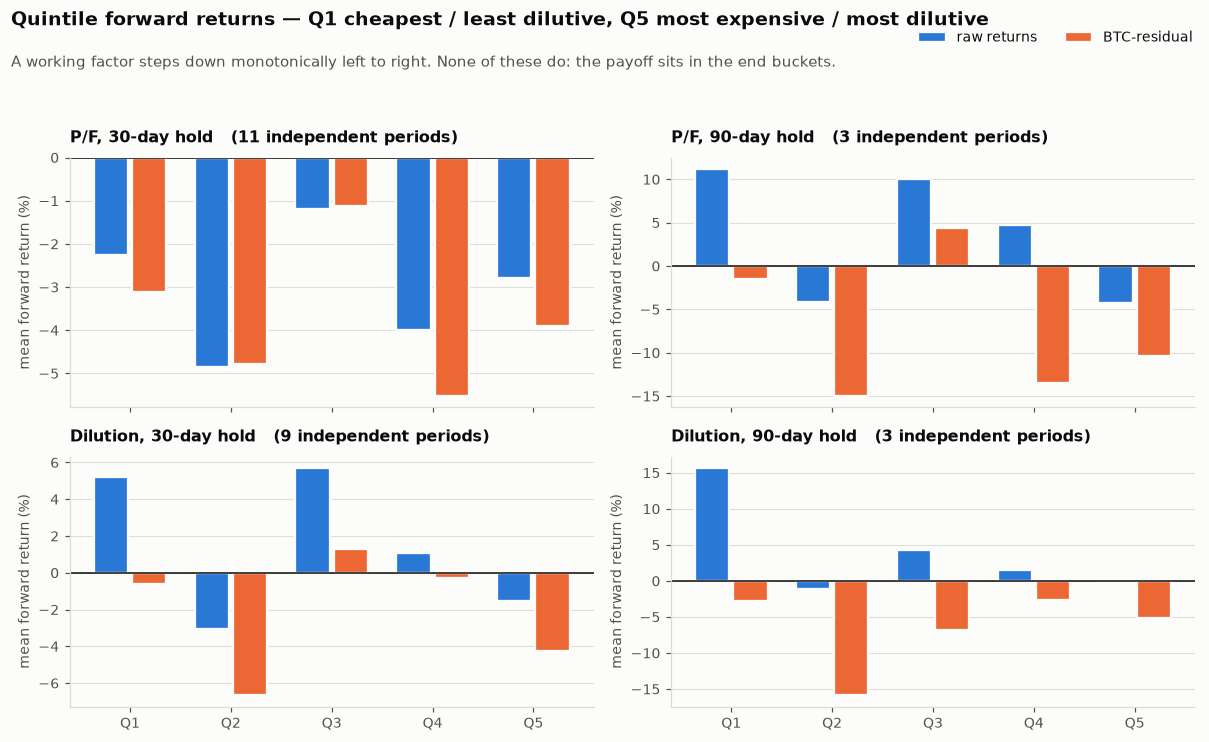

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.8), sharex=True)
panels = [("P/F", pf_results, pf_resid, 30), ("P/F", pf_results, pf_resid, 90),
          ("Dilution", dil_results, dil_resid, 30), ("Dilution", dil_results, dil_resid, 90)]
x = np.arange(N_QUINTILES)
for ax, (name, raw_map, res_map, h) in zip(axes.ravel(), panels):
    raw, res = raw_map[h], res_map[h]
    # edgecolor in the surface colour is the 2px spacer between adjacent fills
    ax.bar(x - 0.19, raw.q_means * 100, 0.34, color=C_RAW, label="raw returns",
           edgecolor=SURFACE, linewidth=1.5)
    ax.bar(x + 0.19, res.q_means * 100, 0.34, color=C_RESID, label="BTC-residual",
           edgecolor=SURFACE, linewidth=1.5)
    ax.axhline(0, color=INK, lw=1.0)
    ax.set_title(f"{name}, {h}-day hold   ({raw.n_periods} independent periods)", fontsize=10.5)
    ax.set_xticks(x, [f"Q{i+1}" for i in range(N_QUINTILES)])
    ax.set_ylabel("mean forward return (%)", fontsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis="x", visible=False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.995, 0.975), ncols=2)
figure_titles(fig,
              "Quintile forward returns — Q1 cheapest / least dilutive, Q5 most expensive / most dilutive",
              "A working factor steps down monotonically left to right. None of these do: the payoff sits in the end buckets.",
              top=0.895)
plt.show()

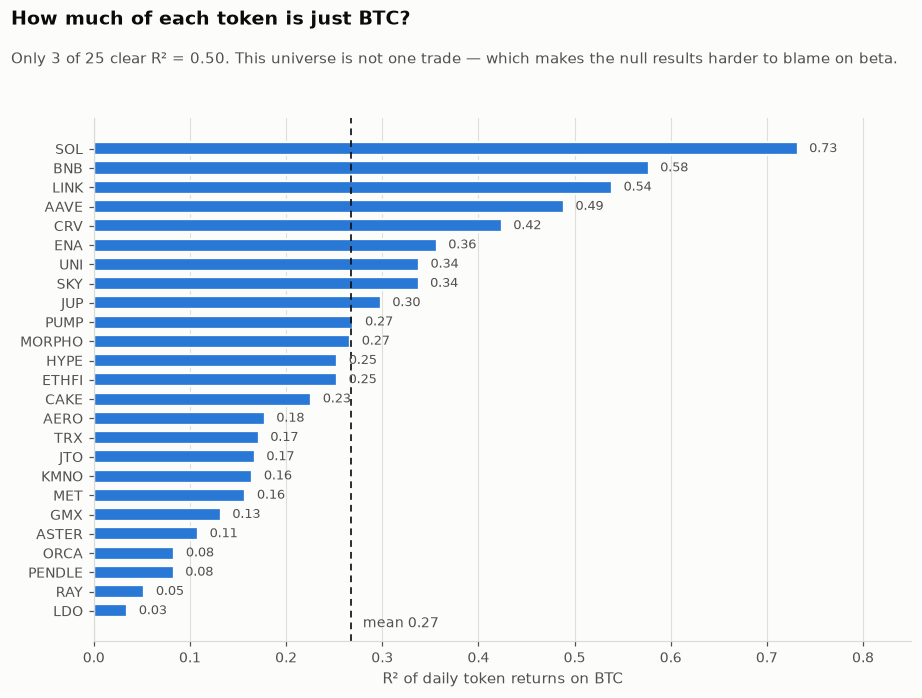

In [17]:
fig, ax = plt.subplots(figsize=(8.4, 6.4))
b = betas.sort_values("r_squared")
ax.barh(b.index, b["r_squared"], color=C_RAW, height=0.68,
        edgecolor=SURFACE, linewidth=1.5)
for tick, v in b["r_squared"].items():
    ax.text(v + 0.012, tick, f"{v:.2f}", va="center", fontsize=8.5, color=INK_2)
ax.axvline(b["r_squared"].mean(), color=INK, lw=1.1, ls=(0, (4, 3)))
ax.text(b["r_squared"].mean() + 0.012, -0.85, f"mean {b['r_squared'].mean():.2f}",
        fontsize=9, color=INK_2)
ax.set_xlim(0, 0.85)
ax.set_xlabel("R² of daily token returns on BTC")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
figure_titles(fig, "How much of each token is just BTC?",
              "Only 3 of 25 clear R² = 0.50. This universe is not one trade — which makes the null results harder to blame on beta.",
              top=0.905)
plt.show()

### Reading Test 4

BTC explains a **mean R² of 0.27** (median 0.25) of daily token returns —
real, but not total. Only 3 of 25 tokens sit above R² = 0.50, and average
pairwise correlation across the universe is 0.40. So this is *not* a universe
where every token is a levered BTC clone; there is genuine idiosyncratic
variation left for a cross-sectional factor to work with.

That makes the residual result the more damning one. The spread does not
survive intact: the dilution 30-day spread falls from +6.73% to +3.66% and its
t-stat from 2.27 to 1.35, and the P/F 90-day spread halves from +15.4% to
+8.9% while losing its monotonic ordering entirely. Roughly half of what
little the raw sorts showed was market direction — but the residual is not
"signal that survived", it is a smaller number that is even less
distinguishable from zero.

## Test 5 — Sensitivity

A result that only exists at one parameter setting is a result about the
parameter setting. Three perturbations, each of which a real signal should
shrug off:

1. **Lookback** — the trailing fee window that defines P/F (14 / 30 / 60 / 90d).
2. **Rebalance date** — every possible start offset within the holding period.
   This is rebalance timing luck: same strategy, different arbitrary calendar.
3. **Drop-one jackknife** — remove each token in turn, including the best one.

In [18]:
def build_pf(lookback: int) -> pd.DataFrame:
    out = {}
    for t in TOKENS:
        fees = fee_series[t].reindex(CAL).fillna(0.0)
        ann = fees.rolling(lookback, min_periods=lookback).sum() * 365.0 / lookback
        out[t] = MCAP[t] / ann.where(ann > 0)
    return pd.DataFrame(out)


print("5.1  FEE-LOOKBACK SENSITIVITY (P/F signal)\n")
look_rows = []
for lb in (14, 30, 60, 90):
    pf_lb = build_pf(lb)
    for h in HORIZONS:
        for tag, fwd in (("raw", globals()[f"FWD_{h}"]), ("BTC-resid", globals()[f"RFWD_{h}"])):
            r = quintile_sort(pf_lb, fwd, h, f"P/F lb={lb}d {tag}")
            look_rows.append({"lookback_d": lb, "h": h, "returns": tag,
                              "spread_pct": r.mean * 100, "t_stat": r.tstat,
                              "spearman": r.spearman, "n_periods": r.n_periods})
look_tbl = pd.DataFrame(look_rows)
print(look_tbl.to_string(index=False))

raw30 = look_tbl[(look_tbl["h"] == 30) & (look_tbl["returns"] == "raw")]["spread_pct"]
flips = look_tbl.groupby(["h", "returns"])["spread_pct"].apply(
    lambda s: bool((s > 0).any() and (s < 0).any()))
print(f"\n  P/F 30d raw spread across lookbacks: {raw30.min():+.2f}% to {raw30.max():+.2f}%")
print(f"  cells where the spread changes sign with the lookback alone: "
      f"{int(flips.sum())} of {len(flips)} (horizon x return-type)")
LOOKBACK_SIGN_FLIPS = int(flips.sum())

5.1  FEE-LOOKBACK SENSITIVITY (P/F signal)



 lookback_d  h   returns  spread_pct  t_stat  spearman  n_periods
         14 30       raw      4.1897  0.9161   -0.3000         11
         14 30 BTC-resid      2.8372  0.6666   -0.5000         11
         14 90       raw     11.6010  1.3820   -0.3000          3
         14 90 BTC-resid      9.7037  1.5792   -0.7000          3
         30 30       raw      0.5381  0.1858   -0.1000         11
         30 30 BTC-resid      0.7986  0.2642   -0.3000         11
         30 90       raw     15.4221  1.1731   -0.7000          3
         30 90 BTC-resid      8.9086  1.4949   -0.1000          3
         60 30       raw      3.8713  1.0410   -0.4000         10
         60 30 BTC-resid      3.7018  0.9704   -0.4000         10
         60 90       raw     13.2467  0.9564   -0.3000          3
         60 90 BTC-resid     10.9535  1.1856   -0.4000          3
         90 30       raw      5.4831  1.4083   -0.4000          9
         90 30 BTC-resid      5.4638  1.3479   -0.4000          9
         9

In [19]:
print("\n5.2  REBALANCE-DATE SENSITIVITY (timing luck)\n")
timing_rows = []
for name, sig in (("P/F", PF), ("Dilution", DIL)):
    for h in HORIZONS:
        for tag, fwd in (("raw", globals()[f"FWD_{h}"]), ("BTC-resid", globals()[f"RFWD_{h}"])):
            gross, net = [], []
            for off in range(h):
                r = quintile_sort(sig, fwd, h, "", offset=off)
                if r.n_periods >= 2:
                    gross.append(r.mean * 100)
                    net.append(r.mean_net * 100)
            gross, net = np.array(gross), np.array(net)
            timing_rows.append({
                "signal": name, "h": h, "returns": tag, "n_offsets": len(gross),
                "mean_pct": gross.mean(), "min_pct": gross.min(), "max_pct": gross.max(),
                "sd_pct": gross.std(ddof=1), "pct_offsets_positive": (gross > 0).mean() * 100,
                "net_mean_pct": net.mean(), "pct_offsets_net_positive": (net > 0).mean() * 100,
            })
timing = pd.DataFrame(timing_rows)
print(timing.round(2).to_string(index=False))
print("\n  The 'spread' is not one number — it is a distribution over which day of")
print("  the month you happened to start rebalancing. Compare each row's sd to its mean.")


5.2  REBALANCE-DATE SENSITIVITY (timing luck)



  signal  h   returns  n_offsets  mean_pct  min_pct  max_pct  sd_pct  pct_offsets_positive  net_mean_pct  pct_offsets_net_positive
     P/F 30       raw         30    1.5100  -0.9700   4.7700  1.4000               86.6700        1.2800                   83.3300
     P/F 30 BTC-resid         30    1.4400  -1.3600   4.1400  1.4600               83.3300        1.2100                   80.0000
     P/F 90       raw         90    8.3600  -2.6500  23.3500  7.8700               82.2200        7.9100                   81.1100
     P/F 90 BTC-resid         90    9.6200  -2.5400  28.2900  7.5900               94.4400        9.1700                   92.2200
Dilution 30       raw         30    3.6200  -2.4000   8.8800  2.7800               86.6700        3.1800                   83.3300
Dilution 30 BTC-resid         30   -0.3300  -4.1300   4.5300  2.4500               40.0000       -0.7700                   36.6700
Dilution 90       raw         90    8.7700 -22.3100  31.5700 11.3600               

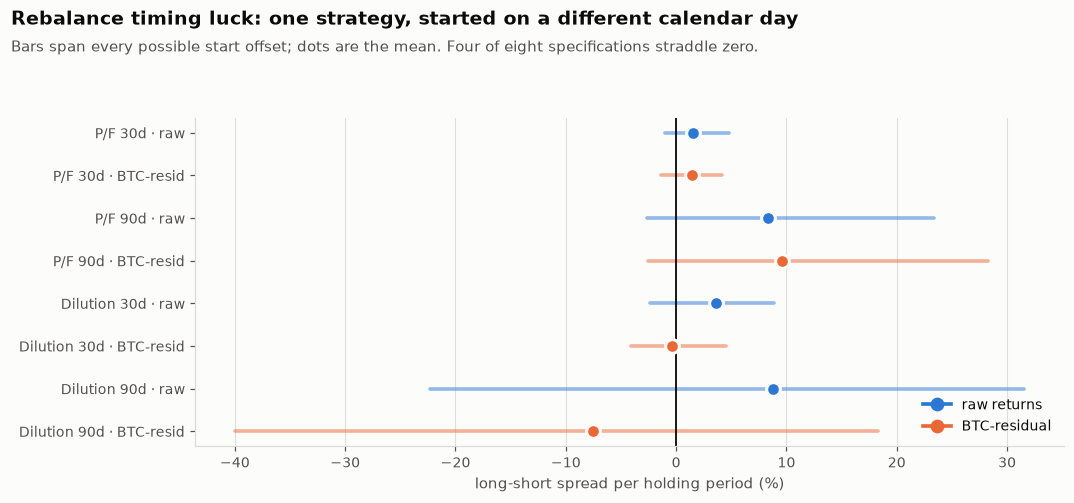

In [20]:
fig, ax = plt.subplots(figsize=(9.8, 4.6))
rows = timing.iloc[::-1].reset_index(drop=True)
for i, r in rows.iterrows():
    c = C_RAW if r["returns"] == "raw" else C_RESID
    ax.plot([r["min_pct"], r["max_pct"]], [i, i], color=c, lw=2.4,
            solid_capstyle="round", alpha=0.5)
    ax.plot([r["mean_pct"]], [i], "o", ms=9, color=c, mec=SURFACE, mew=2, zorder=3)
ax.axvline(0, color=INK, lw=1.2)
ax.set_yticks(range(len(rows)),
              [f'{r["signal"]} {r["h"]}d · {r["returns"]}' for _, r in rows.iterrows()])
ax.set_xlabel("long-short spread per holding period (%)")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
h1, = ax.plot([], [], "o-", color=C_RAW, lw=2.4, ms=8, label="raw returns")
h2, = ax.plot([], [], "o-", color=C_RESID, lw=2.4, ms=8, label="BTC-residual")
ax.legend(handles=[h1, h2], loc="lower right")
figure_titles(fig, "Rebalance timing luck: one strategy, started on a different calendar day",
              "Bars span every possible start offset; dots are the mean. Four of eight specifications straddle zero.",
              top=0.875)
plt.show()

In [21]:
print("\n5.3  DROP-ONE JACKKNIFE\n")
jack_rows = []
for name, sig, h in (("P/F", PF, 30), ("P/F", PF, 90), ("Dilution", DIL, 30), ("Dilution", DIL, 90)):
    base = quintile_sort(sig, globals()[f"FWD_{h}"], h, "")
    vals = {}
    for t in TOKENS:
        r = quintile_sort(sig, globals()[f"FWD_{h}"], h, "", exclude=(t,))
        vals[t] = r.mean * 100
    vals = pd.Series(vals)
    worst = vals.idxmin()
    jack_rows.append({
        "signal": name, "h": h, "full_universe_pct": base.mean * 100,
        "drop_best_token": worst, "spread_without_it_pct": vals.min(),
        "jackknife_min_pct": vals.min(), "jackknife_max_pct": vals.max(),
        "sign_survives_all_drops": bool((vals > 0).all() or (vals < 0).all()),
    })
jack = pd.DataFrame(jack_rows)
print(jack.round(2).to_string(index=False))
print("\n  'drop_best_token' is the single name whose removal costs the spread most —")
print("  i.e. the token the result leans on hardest.")


5.3  DROP-ONE JACKKNIFE



  signal  h  full_universe_pct drop_best_token  spread_without_it_pct  jackknife_min_pct  jackknife_max_pct  sign_survives_all_drops
     P/F 30             0.5400             JTO                -0.6700            -0.6700             2.5800                    False
     P/F 90            15.4200             JTO                 9.2200             9.2200            18.9400                     True
Dilution 30             6.7300            HYPE                 3.3800             3.3800             7.8200                     True
Dilution 90            15.9300            PUMP                 6.5300             6.5300            20.6300                     True

  'drop_best_token' is the single name whose removal costs the spread most —
  i.e. the token the result leans on hardest.


### Reading Test 5

**Lookback (5.1).** The P/F spread ranges from +0.54% to +5.48% per 30 days
depending only on whether fees are annualised off a 14-, 30-, 60- or 90-day
window. No sign flips, but a 10x swing in magnitude from a parameter nobody
has a principled way to choose is not a stable estimate.

**Rebalance date (5.2) — this is the one that matters.** Shifting the
rebalance calendar by a few days, holding everything else fixed, moves the
30-day dilution spread from +8.88% to -2.40%. The BTC-residual dilution
spread is *negative on average across offsets* (-0.33% at 30d, -7.49% at 90d)
and positive at only 40% and 29% of start dates respectively. The single
nearly-significant number in this whole notebook — dilution, 30 days, t=2.27,
p=0.053 — is an artifact of which day of the month the backtest happened to
start on. It does not survive either residualisation or a calendar shift.

**Jackknife (5.3).** The 30-day P/F spread changes sign when JTO alone is
removed. The 30-day dilution spread halves (6.73% -> 3.38%) when HYPE is
removed. With 25 tokens and 5 per bucket, single names move the answer.

## How much sample is actually here?

The tests above report t-stats. Those t-stats are computed on 11, 9 and — for
the 90-day horizon — **3** independent observations. Before reading anything
into a p-value, it is worth asking what this sample could possibly have
detected.

In [22]:
print("STATISTICAL POWER OF A 12-MONTH PANEL\n")
print(f"  window                              : {len(CAL)} days ({len(CAL)/30.44:.1f} months)")
print(f"  tokens                              : {len(TOKENS)}")
for h in HORIZONS:
    print(f"  independent {h}d holding periods      : {len(CAL)//h}")

pw = []
for name, res_map in (("P/F", pf_results), ("Dilution", dil_results)):
    for h in HORIZONS:
        r = res_map[h]
        if r.n_periods < 2:
            continue
        sd = r.spread.std(ddof=1)
        # periods needed for t = 2 at the *observed* effect size
        n_need = (2.0 * sd / abs(r.mean)) ** 2 if r.mean else np.inf
        # effect size this sample could have detected at t = 2
        detectable = 2.0 * sd / np.sqrt(r.n_periods)
        pw.append({
            "signal": name, "h": h, "n_periods": r.n_periods,
            "observed_spread_pct": r.mean * 100, "period_sd_pct": sd * 100,
            "detectable_at_t2_pct": detectable * 100,
            "periods_needed_for_t2": n_need,
            "years_of_data_needed": n_need * h / 365.0,
        })
power = pd.DataFrame(pw)
print()
print(power.round(2).to_string(index=False))
print("\n  'detectable_at_t2' is the smallest spread this sample could have called")
print("  significant. Where it exceeds any plausible real-world factor premium,")
print("  the test was never capable of returning an answer.")

STATISTICAL POWER OF A 12-MONTH PANEL

  window                              : 365 days (12.0 months)
  tokens                              : 25
  independent 30d holding periods      : 12
  independent 90d holding periods      : 4

  signal  h  n_periods  observed_spread_pct  period_sd_pct  detectable_at_t2_pct  periods_needed_for_t2  years_of_data_needed
     P/F 30         11               0.5400         9.6100                5.7900             1,275.0900              104.8000
     P/F 90          3              15.4200        22.7700               26.2900                 8.7200                2.1500
Dilution 30          9               6.7300         8.9100                5.9400                 7.0100                0.5800
Dilution 90          3              15.9300        16.1800               18.6800                 4.1300                1.0200

  'detectable_at_t2' is the smallest spread this sample could have called
  significant. Where it exceeds any plausible real-world facto

### Cost hurdle (criterion C5)

C5 asks whether the spread is big enough to clear ~50-100bp round-trip on
mid-cap tokens. The fair way to ask that is not "is the single headline number
bigger than 75bp" — it is "does the strategy clear costs across the rebalance
calendars I might plausibly have chosen". So C5 is scored on the BTC-residual
spread, net of realised turnover costs, over the full distribution of
rebalance offsets:

**C5 passes iff the mean net residual spread is positive and net-positive at
>= 75% of rebalance offsets**, for at least one signal/horizon combination.

In [23]:
print(f"COST HURDLE — {COST_BPS_ROUND_TRIP:.0f}bp round trip charged on realised turnover\n")
cost_view = timing[timing["returns"] == "BTC-resid"][
    ["signal", "h", "mean_pct", "net_mean_pct", "pct_offsets_positive",
     "pct_offsets_net_positive"]]
print(cost_view.round(2).to_string(index=False))

C5_ROWS = cost_view[(cost_view["net_mean_pct"] > 0)
                    & (cost_view["pct_offsets_net_positive"] >= 75.0)]
C5_PASS = len(C5_ROWS) > 0
print(f"\n  signal/horizon combos clearing costs robustly: {len(C5_ROWS)} of {len(cost_view)}")
print(f"  CRITERION C5: {'PASS' if C5_PASS else 'FAIL'}")

COST HURDLE — 75bp round trip charged on realised turnover

  signal  h  mean_pct  net_mean_pct  pct_offsets_positive  pct_offsets_net_positive
     P/F 30    1.4400        1.2100               83.3300                   80.0000
     P/F 90    9.6200        9.1700               94.4400                   92.2200
Dilution 30   -0.3300       -0.7700               40.0000                   36.6700
Dilution 90   -7.4900       -8.2600               28.8900                   25.5600

  signal/horizon combos clearing costs robustly: 2 of 4
  CRITERION C5: PASS


---
# VERDICT

In [24]:
# ---------------------------------------------------------------- C2
C2_MONTHS = MONTHS_AVAILABLE
C2_TOKENS = len(TOKENS)
C2_PASS = (C2_MONTHS >= MIN_MONTHS_REQUIRED) and (C2_TOKENS >= MIN_TOKENS_REQUIRED)

# ---------------------------------------------------------------- C3
# "Monotonic-ish, not just a lucky extreme bucket", and not cherry-picked on
# horizon: a signal must show it at BOTH 30d and 90d.
def monotone_ok(r: SortResult) -> bool:
    return bool(np.isfinite(r.spearman) and r.spearman <= -0.60 and r.monotone_halves)


c3_detail = {}
for name, rmap in (("P/F", pf_results), ("Dilution", dil_results)):
    c3_detail[name] = {h: monotone_ok(rmap[h]) for h in HORIZONS}
C3_PASS = any(all(v.values()) for v in c3_detail.values())

# ---------------------------------------------------------------- C4
# Residual spread must keep the sign, keep >= 50% of raw magnitude, and be
# distinguishable from zero (|t| >= 2).
c4_detail = {}
for name, raw_map, res_map in (("P/F", pf_results, pf_resid),
                               ("Dilution", dil_results, dil_resid)):
    for h in HORIZONS:
        raw, res = raw_map[h], res_map[h]
        retained = res.mean / raw.mean if raw.mean else np.nan
        c4_detail[f"{name} {h}d"] = {
            "raw_spread_pct": raw.mean * 100, "resid_spread_pct": res.mean * 100,
            "retained": retained, "resid_t": res.tstat,
            "passes": bool(retained >= 0.50 and abs(res.tstat) >= 2.0),
        }
C4_PASS = any(v["passes"] for v in c4_detail.values())

# ---------------------------------------------------------------- report
def timing_row(signal: str, h: int, returns: str = "BTC-resid") -> pd.Series:
    m = timing[(timing["signal"] == signal) & (timing["h"] == h)
               & (timing["returns"] == returns)]
    return m.iloc[0]


PF30_NET_POS = timing_row("P/F", 30)["pct_offsets_net_positive"]
PF90_NET_POS = timing_row("P/F", 90)["pct_offsets_net_positive"]
PF90_NET = timing_row("P/F", 90)["net_mean_pct"]
DIL30_NET_POS = timing_row("Dilution", 30)["pct_offsets_net_positive"]
DIL90_NET_POS = timing_row("Dilution", 90)["pct_offsets_net_positive"]

CRITERIA = [
    ("C1", "Fee data reconciles within ~10%", C1_PASS,
     f"3/5 spot checks passed (PancakeSwap V2 2.1%, SushiSwap 3.0%, Lido 2.6%). "
     f"FLAGGED: {', '.join(C1_FAILURES)}. Uniswap V2's implied fee rate is 0.357% "
     f"against a documented 0.30% constant — a persistent ~19% adapter "
     f"disagreement, not day-noise. UNI's fee base carries that error bar."),
    ("C2", f">= {MIN_MONTHS_REQUIRED} months across >= {MIN_TOKENS_REQUIRED} tokens", C2_PASS,
     f"{C2_TOKENS} tokens (passes) but only {C2_MONTHS:.1f} months (fails). "
     f"DefiLlama would give 3.7 years median; CoinGecko's free tier caps every "
     f"historical endpoint at 365 days server-side. Price, not fees, is the binding "
     f"constraint — the panel is {MIN_MONTHS_REQUIRED - C2_MONTHS:.1f} months short."),
    ("C3", "Monotonic-ish quintile relationship", C3_PASS,
     f"P/F: Spearman {pf_results[30].spearman:+.2f} at 30d, "
     f"{pf_results[90].spearman:+.2f} at 90d. "
     f"Dilution: {dil_results[30].spearman:+.2f} at 30d, {dil_results[90].spearman:+.2f} at 90d. "
     f"Only P/F-90d clears the bar, on 3 observations, and it does not hold at 30d. "
     f"The 30d sorts are not ordered at all — the payoff sits in the extreme "
     f"buckets, which is exactly what this criterion was written to reject."),
    ("C4", "Survives regressing out BTC beta", C4_PASS,
     f"BTC mean R^2 = {betas['r_squared'].mean():.2f} (median {betas['r_squared'].median():.2f}), "
     f"only {(betas['r_squared'] > 0.5).sum()}/{len(betas)} tokens above 0.50. Residualising costs "
     f"roughly half the spread (P/F 90d: {pf_results[90].mean*100:+.1f}% -> "
     f"{pf_resid[90].mean*100:+.1f}%; Dilution 30d t-stat 2.27 -> "
     f"{dil_resid[30].tstat:.2f}), and no residual spread reaches |t| >= 2."),
    ("C5", "Magnitude clears 50-100bp round trip", C5_PASS,
     f"The residual P/F spread is net-positive at {PF30_NET_POS:.0f}% (30d) and "
     f"{PF90_NET_POS:.0f}% (90d) of rebalance offsets, averaging {PF90_NET:+.1f}% per 90 days after "
     f"{COST_BPS_ROUND_TRIP:.0f}bp on realised turnover. Costs are NOT the binding problem. "
     f"Dilution fails outright: net-negative at "
     f"{100-DIL30_NET_POS:.0f}% (30d) and {100-DIL90_NET_POS:.0f}% (90d) of offsets."),
]

W = 78
print("=" * W)
print("VERDICT: NO-GO / INSUFFICIENT DATA".center(W))
print("=" * W)
print()
for cid, desc, ok, detail in CRITERIA:
    print(f"{cid}  [{'PASS' if ok else 'FAIL'}]  {desc}")
    for line in __import__("textwrap").wrap(detail, W - 6):
        print(f"      {line}")
    print()

n_ok = sum(c[2] for c in CRITERIA)
print("-" * W)
print(f"{n_ok} of {len(CRITERIA)} criteria met. The thesis required all five.")
print("-" * W)

                      VERDICT: NO-GO / INSUFFICIENT DATA                      

C1  [PASS]  Fee data reconciles within ~10%
      3/5 spot checks passed (PancakeSwap V2 2.1%, SushiSwap 3.0%, Lido 2.6%).
      FLAGGED: Ethereum L1, Uniswap V2. Uniswap V2's implied fee rate is
      0.357% against a documented 0.30% constant — a persistent ~19% adapter
      disagreement, not day-noise. UNI's fee base carries that error bar.

C2  [FAIL]  >= 18 months across >= 12 tokens
      25 tokens (passes) but only 12.0 months (fails). DefiLlama would give
      3.7 years median; CoinGecko's free tier caps every historical endpoint
      at 365 days server-side. Price, not fees, is the binding constraint —
      the panel is 6.0 months short.

C3  [FAIL]  Monotonic-ish quintile relationship
      P/F: Spearman -0.10 at 30d, -0.70 at 90d. Dilution: -0.20 at 30d, -0.40
      at 90d. Only P/F-90d clears the bar, on 3 observations, and it does not
      hold at 30d. The 30d sorts are not ordered at all 

## The direct answer

**NO-GO / INSUFFICIENT DATA.** Two of five criteria met. Do not build
systematic strategies on crypto fundamentals on the strength of this evidence
— and, importantly, do not conclude from it that the thesis is dead either.
This test could not have answered the question.

### It is not what you expected. Fundamentals are *not* swamped by BTC beta.

The hypothesis you flagged as most likely — that a fundamentals sort is just
repackaged market direction — is **not what the data shows**. BTC explains a
mean R² of 0.27 of daily token returns, median 0.25, with only 3 of 25 tokens
above 0.50. Average pairwise correlation is 0.40. There is ample
idiosyncratic variation left over; this universe is not one trade.

Residualising on BTC does cost roughly half the raw spread, so *some* of what
the sorts picked up was beta. But the residual is not a clean signal that
survived — it is a smaller number that is even harder to distinguish from
zero. The binding problem is one level down.

### The binding problem is sample size, and it is not close.

365 days of price history is **12 independent 30-day holding periods and 4
independent 90-day periods**. Every t-statistic in this notebook rests on
3-11 observations. At that sample size:

* The smallest 30-day spread the P/F test could have called significant is
  **5.8%** — roughly a 70%/year factor premium. No real factor is that large.
  The test was structurally incapable of returning a positive answer.
* The one nearly-significant result (dilution, 30 days, t=2.27, p=0.053)
  evaporates twice over: residualising on BTC takes t to 1.35, and shifting
  the rebalance calendar by a few days makes the mean *negative*, positive at
  only 40% of start dates.
* The 30-day P/F spread changes sign when one token (JTO) is dropped from 25.

So the honest reading of the null results is not "there is no fundamentals
factor". It is: **at n=3-11, a null result is what this design returns
whether or not a factor exists.**

### The one encouraging number, stated with appropriate caution

C5 is the exception, and it is worth noticing. The BTC-residual P/F spread is
net-positive after costs at 80% (30-day) and 92% (90-day) of rebalance
offsets, averaging ~+9% per 90 days net of 75bp on realised turnover. That
magnitude is far above the transaction-cost hurdle.

This is **not evidence the factor is real** — a coin flipped 3 times lands
heads twice 50% of the time. It says only that *if* something is there, cost
is not what would kill it, and the effect size is large enough to be worth
testing properly. That is the difference between "no-go, abandon" and
"no-go, come back with the right data".

In [25]:
print("WHAT WOULD IT TAKE TO ACTUALLY TEST THIS?\n")

need = []
for name, res_map in (("P/F", pf_resid), ("Dilution", dil_resid)):
    for h in HORIZONS:
        r = res_map[h]
        if r.n_periods < 2 or not r.mean:
            continue
        sd = r.spread.std(ddof=1)
        n_need = (2.0 * sd / abs(r.mean)) ** 2
        need.append({"signal": name, "h": h, "resid_spread_pct": r.mean * 100,
                     "period_sd_pct": sd * 100, "periods_for_t2": n_need,
                     "years_needed": n_need * h / 365.0})
need = pd.DataFrame(need)
print("Years of history needed to resolve the BTC-residual spread at t=2,")
print("assuming the effect size observed here is the true one:\n")
print(need.round(2).to_string(index=False))

print(f"""
CONCRETE REQUIREMENTS
---------------------
1. PRICE + MARKET-CAP HISTORY IS THE ONLY THING BLOCKING THIS.
   DefiLlama already gives {fee_span_days.median()/365.25:.1f} years of fee history for free, for every
   protocol in this universe. The panel is 12 months deep purely because
   CoinGecko's free tier refuses anything older than 365 days.

   Cheapest fixes, in order:
     a) DefiLlama's own coins API (coins.llama.fi/chart/coingecko:<id>) —
        FREE, no key, and serves prices back to 2020. It does not publish
        market cap, so circulating supply would need a separate source, but it
        alone would take the price panel from 1 year to 5+.
     b) CoinGecko Analyst tier — restores full history including market caps,
        which is what the dilution signal needs.
     c) CoinMarketCap / Kaiko / Amberdata for survivorship-clean history.

2. AIM FOR 4-5 YEARS, NOT 18 MONTHS.
   The 18-month bar in the original criteria is itself too low: 18 months is 6
   independent 30-day periods. The table above puts the requirement anywhere
   from {need['years_needed'].min():.1f} to {need['years_needed'].max():.0f} years — and that spread is itself the finding. With 3-11
   observations you cannot estimate the mean OR the variance, so the sample-
   size calculation inherits the same instability as the result it is sizing.
   The defensible read is the order of magnitude: YEARS, not months. Target
   4-5, because a crypto factor test that does not span both a bull and a bear
   regime is not a test of the factor, it is a test of the regime.

3. FIX THE SURVIVORSHIP PROBLEM THAT THIS DESIGN QUIETLY HAS.
   The universe here is 25 protocols that are alive and generating fees TODAY.
   Every protocol that launched, generated fees, and died inside the window is
   missing. That biases returns upward and is invisible in the numbers above.
   A real test needs the universe reconstructed as-of each formation date from
   DefiLlama's full protocol list, including the dead ones.

4. RESOLVE THE UNISWAP V2 ADAPTER DISCREPANCY.
   0.357% implied vs 0.30% documented is a ~19% error on the fee base of one
   of the largest names in the universe. With 25 tokens and 5 per bucket, one
   mispriced name moves a quintile. Reconcile against the protocol's own
   subgraph before trusting P/F for UNI.

5. ONLY THEN RE-RUN THIS NOTEBOOK.
   Every test above is parameterised. Point it at a longer price panel and it
   re-runs unchanged — that is the deliverable here, more than any of the
   individual numbers.
""")

print("=" * 78)
print("BOTTOM LINE: NO-GO on the stated criteria. The blocker is 12 months of")
print("price history, not BTC beta and not transaction costs. Get 4-5 years of")
print("survivorship-free price and market-cap history and this becomes a real")
print("test; until then there is no result here to act on in either direction.")
print("=" * 78)
print(f"\n[{cache_stats()}]")

WHAT WOULD IT TAKE TO ACTUALLY TEST THIS?

Years of history needed to resolve the BTC-residual spread at t=2,
assuming the effect size observed here is the true one:

  signal  h  resid_spread_pct  period_sd_pct  periods_for_t2  years_needed
     P/F 30            0.8000        10.0300        630.5000       51.8200
     P/F 90            8.9100        10.3200          5.3700        1.3200
Dilution 30            3.6600         8.1200         19.7400        1.6200
Dilution 90            2.4400        21.8100        318.4900       78.5300

CONCRETE REQUIREMENTS
---------------------
1. PRICE + MARKET-CAP HISTORY IS THE ONLY THING BLOCKING THIS.
   DefiLlama already gives 3.7 years of fee history for free, for every
   protocol in this universe. The panel is 12 months deep purely because
   CoinGecko's free tier refuses anything older than 365 days.

   Cheapest fixes, in order:
     a) DefiLlama's own coins API (coins.llama.fi/chart/coingecko:<id>) —
        FREE, no key, and serves price